In [1]:
%pip install transformers datasets accelerate scikit-learn evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
import evaluate

In [25]:
# --- CONFIGURATION ---
MODEL_CKPT = "distilbert-base-uncased"
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 3
FILE_NAME = "/content/balanced_data.csv"

In [26]:
# --- 1. LOAD & PREP DATA ---
print(">> Loading data...")
df = pd.read_csv(FILE_NAME)

# Map labels to integers
# Ensure your CSV labels match these keys exactly (case sensitive)
label_map = {"positive": 0, "neutral": 1, "passive_aggressive": 2}

# Force the mapping and overwrite the 'label' column
df['label'] = df['label'].map(label_map)

# Drop any rows where mapping failed (e.g. if CSV had "Positive" instead of "positive")
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

# Convert to Hugging Face Dataset
# We select only the columns we need to start with
hf_dataset = Dataset.from_pandas(df[["text", "label"]])

>> Loading data...


In [27]:
# --- 2. SPLIT DATA (Train / Validation / Test) ---
# Split 80% Train, 20% Temp
train_testvalid = hf_dataset.train_test_split(test_size=0.2, seed=42)

# Split that 20% Temp into half (10% Val, 10% Test)
test_valid = train_testvalid['test'].train_test_split(test_size=0.5, seed=42)

dataset_clean = DatasetDict({
    'train': train_testvalid['train'],
    'validation': test_valid['train'],
    'test': test_valid['test']
})

print(f">> Data Split:\n{dataset_clean}")

>> Data Split:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3385
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 423
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 424
    })
})


In [28]:
# --- 3. TOKENIZATION ---
print(">> Tokenizing...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# CRITICAL FIX: Identify columns to drop (the raw strings)
# If we don't drop 'text', the Trainer crashes trying to convert words to tensors.
columns_to_remove = dataset_clean["train"].column_names
if "label" in columns_to_remove:
    columns_to_remove.remove("label") # Keep the label!

tokenized_datasets = dataset_clean.map(
    tokenize_function,
    batched=True,
    remove_columns=columns_to_remove # <--- This prevents the ValueError
)

print(f">> Columns sent to model: {tokenized_datasets['train'].column_names}")
# Should look like: ['label', 'input_ids', 'token_type_ids', 'attention_mask']

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

>> Tokenizing...


Map:   0%|          | 0/3385 [00:00<?, ? examples/s]

Map:   0%|          | 0/423 [00:00<?, ? examples/s]

Map:   0%|          | 0/424 [00:00<?, ? examples/s]

>> Columns sent to model: ['label', 'input_ids', 'attention_mask']


In [29]:
# --- 4. METRICS ---
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    # Average='weighted' accounts for class imbalance
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")
    return {**acc, **f1}

In [30]:
# --- 5. MODEL SETUP ---
id2label = {0: "POSITIVE", 1: "NEUTRAL", 2: "PASSIVE_AGGRESSIVE"}
label2id = {"POSITIVE": 0, "NEUTRAL": 1, "PASSIVE_AGGRESSIVE": 2}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CKPT,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
# --- 6. TRAINING ---
training_args = TrainingArguments(
    output_dir="./pmlm_checkpoints",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"], # Eval on validation set
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print(">> Starting Training...")
trainer.train()

/tmp/ipython-input-111975094.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


>> Starting Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.380540,0.865248,0.865800
2,No log,0.313255,0.893617,0.893574
3,0.362100,0.326129,0.900709,0.900667


TrainOutput(global_step=636, training_loss=0.31564523588936283, metrics={'train_runtime': 138.3134, 'train_samples_per_second': 73.42, 'train_steps_per_second': 4.598, 'total_flos': 336307605799680.0, 'train_loss': 0.31564523588936283, 'epoch': 3.0})

In [32]:
# --- 7. EVALUATION & SAVE ---
print("\n>> Final Test Set Evaluation:")
test_results = trainer.predict(tokenized_datasets["test"])
print(test_results.metrics)

trainer.save_model("./pmlm_model_final")
print(">> Model saved to ./pmlm_model_final")


>> Final Test Set Evaluation:


{'test_loss': 0.3364448547363281, 'test_accuracy': 0.8867924528301887, 'test_f1': 0.8864579757031464, 'test_runtime': 1.6475, 'test_samples_per_second': 257.361, 'test_steps_per_second': 16.389}
>> Model saved to ./pmlm_model_final


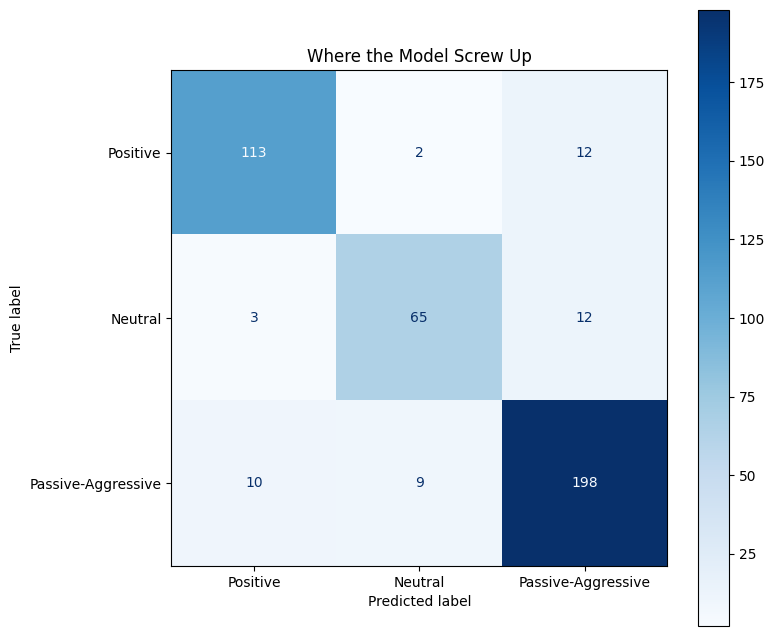

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Get predictions on the test set again
predictions = trainer.predict(tokenized_datasets["test"])
y_preds = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# 2. Plot it
labels = ["Positive", "Neutral", "Passive-Aggressive"]
cm = confusion_matrix(y_true, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap="Blues", ax=ax, values_format='d')
plt.title("Where the Model Screw Up")
plt.show()

In [34]:
import shutil

# Zip the folder
shutil.make_archive("pmlm_model_final", 'zip', "./pmlm_model_final")

print("Zipping complete. Download 'pmlm_model_final.zip' from the files sidebar on the left.")

Zipping complete. Download 'pmlm_model_final.zip' from the files sidebar on the left.
